In [1]:
# imports section

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score


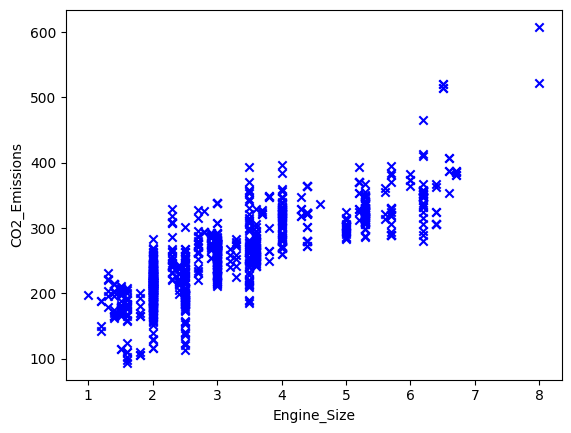

In [2]:
def build_plot(file_path, x, y):
    data = pd.read_csv(file_path)
    plt.scatter(data[x], data[y], c='blue', marker='x')
    plt.xlabel(x)
    plt.ylabel(y)
    return plt

build_plot('resources/CO2_emission.csv', 'Engine_Size', 'CO2_Emissions').show()


In [3]:
def extract_texts_from_file(file_path):
    """
    Extract the text data from the csv file

    Args:
        file_path (str): Relative location of the csv file in the project.

    Returns:
        list: The list of texts as strings.
    """
    df = pd.read_csv(file_path)
    return df.to_dict('records')

data = extract_texts_from_file('resources/heart.csv')
print(data[:50])

[{'age': 63, 'sex': 1, 'cp': 3, 'trtbps': 145, 'chol': 233, 'fbs': 1, 'restecg': 0, 'thalachh': 150, 'exng': 0, 'oldpeak': 2.3, 'slp': 0, 'caa': 0, 'thall': 1, 'output': 1}, {'age': 37, 'sex': 1, 'cp': 2, 'trtbps': 130, 'chol': 250, 'fbs': 0, 'restecg': 1, 'thalachh': 187, 'exng': 0, 'oldpeak': 3.5, 'slp': 0, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 41, 'sex': 0, 'cp': 1, 'trtbps': 130, 'chol': 204, 'fbs': 0, 'restecg': 0, 'thalachh': 172, 'exng': 0, 'oldpeak': 1.4, 'slp': 2, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 56, 'sex': 1, 'cp': 1, 'trtbps': 120, 'chol': 236, 'fbs': 0, 'restecg': 1, 'thalachh': 178, 'exng': 0, 'oldpeak': 0.8, 'slp': 2, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 57, 'sex': 0, 'cp': 0, 'trtbps': 120, 'chol': 354, 'fbs': 0, 'restecg': 1, 'thalachh': 163, 'exng': 1, 'oldpeak': 0.6, 'slp': 2, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 57, 'sex': 1, 'cp': 0, 'trtbps': 140, 'chol': 192, 'fbs': 0, 'restecg': 1, 'thalachh': 148, 'exng': 0, 'oldpeak': 0.4, 'slp': 

c:\Users\Valentyn\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model Comparison for Heart Conditions Predictions:
Model                                              Accuracy  
LogisticRegression (C=0.1, solver=lbfgs)           0.8852459016
LogisticRegression (C=0.1, solver=liblinear)       0.8852459016
LogisticRegression (C=1.0, solver=lbfgs)           0.8852459016
RidgeClassifier (alpha=10.0)                       0.8852459016
RidgeClassifier (alpha=100.0)                      0.8852459016
LogisticRegression (C=0.01, solver=lbfgs)          0.8688524590
LogisticRegression (C=0.01, solver=liblinear)      0.8688524590
LogisticRegression (C=1.0, solver=liblinear)       0.8688524590
RidgeClassifier (alpha=0.1)                        0.8688524590
RidgeClassifier (alpha=1.0)                        0.8688524590
LogisticRegression (C=10.0, solver=lbfgs)          0.8524590164
LogisticRegression (C=10.0, solver=liblinear)      0.8524590164
SGDClassifier (loss=log_loss, alpha=0.001)         0.5409836066
SGDClassifier (loss=log_loss, alpha=0.01)          0.54

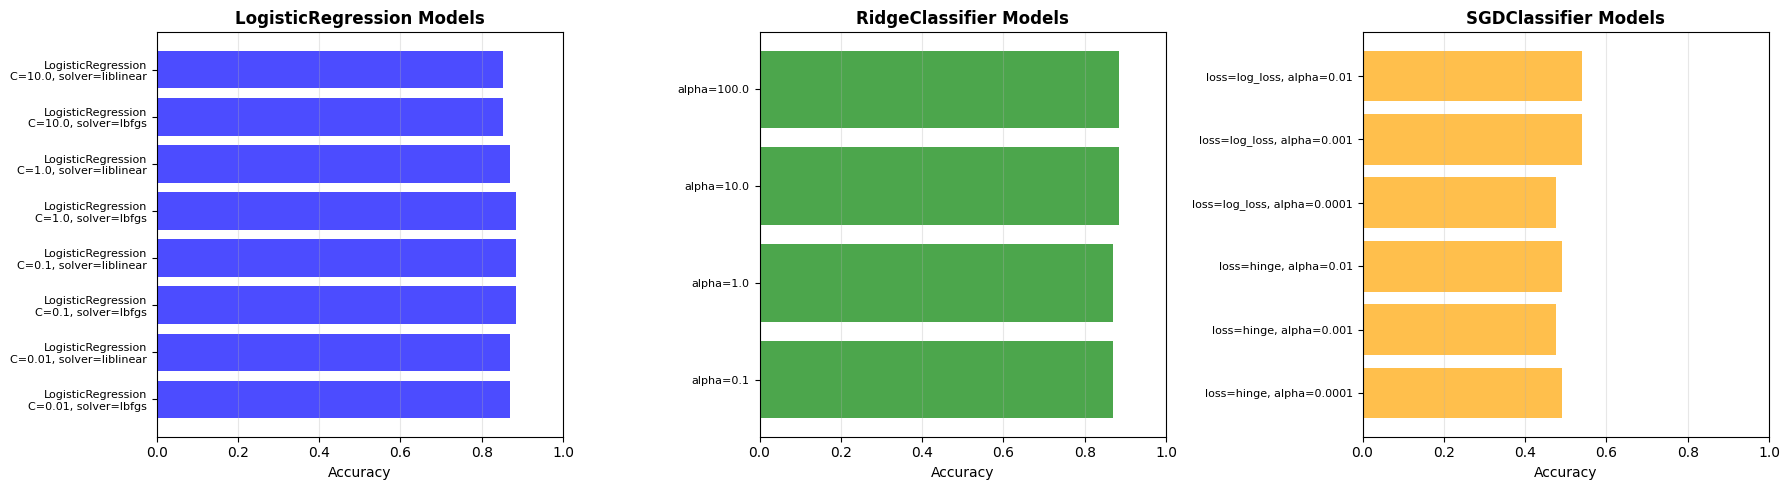

In [4]:
data_heart = extract_texts_from_file('resources/heart.csv')
df_heart = pd.DataFrame(data_heart)

X = df_heart.drop('output', axis=1).values
y = df_heart['output'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

models_to_test = {}

for C in [0.01, 0.1, 1.0, 10.0]:
    for solver in ['lbfgs', 'liblinear']:
        model = LogisticRegression(C=C, solver=solver, max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        models_to_test[f'LogisticRegression (C={C}, solver={solver})'] = {
            'model': model, 'accuracy': accuracy, 'type': 'LogisticRegression'
        }

for alpha in [0.1, 1.0, 10.0, 100.0]:
    model = RidgeClassifier(alpha=alpha, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    models_to_test[f'RidgeClassifier (alpha={alpha})'] = {
        'model': model, 'accuracy': accuracy, 'type': 'RidgeClassifier'
    }

for loss in ['hinge', 'log_loss']:
    for alpha in [0.0001, 0.001, 0.01]:
        model = SGDClassifier(loss=loss, alpha=alpha, random_state=42, max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        models_to_test[f'SGDClassifier (loss={loss}, alpha={alpha})'] = {
            'model': model, 'accuracy': accuracy, 'type': 'SGDClassifier'
        }

print("Model Comparison for Heart Conditions Predictions:")
print("=" * 70)
print(f"{'Model':<50s} {'Accuracy':<10s}")
print("=" * 70)

logistic_models = {k: v for k, v in models_to_test.items() if v['type'] == 'LogisticRegression'}
ridge_models = {k: v for k, v in models_to_test.items() if v['type'] == 'RidgeClassifier'}
sgd_models = {k: v for k, v in models_to_test.items() if v['type'] == 'SGDClassifier'}

all_sorted = sorted(models_to_test.items(), key=lambda x: x[1]['accuracy'], reverse=True)

for model_name, model_info in all_sorted:
    print(f"{model_name:<50s} {model_info['accuracy']:<10.10f}")

print("=" * 70)

best_logistic = max(logistic_models.items(), key=lambda x: x[1]['accuracy'])
best_ridge = max(ridge_models.items(), key=lambda x: x[1]['accuracy'])
best_sgd = max(sgd_models.items(), key=lambda x: x[1]['accuracy'])

print(f"\nBest LogisticRegression: {best_logistic[0]} (accuracy: {best_logistic[1]['accuracy']:.10f})")
print(f"Best RidgeClassifier: {best_ridge[0]} (accuracy: {best_ridge[1]['accuracy']:.10f})")
print(f"Best SGDClassifier: {best_sgd[0]} (accuracy: {best_sgd[1]['accuracy']:.10f})")

best_overall = all_sorted[0]
print(f"\n{'='*70}")
print(f"Best Overall Model: {best_overall[0]} (accuracy: {best_overall[1]['accuracy']:.10f})")
print(f"{'='*70}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

logistic_accs = [v['accuracy'] for v in logistic_models.values()]
logistic_names = [k.split('(')[0].strip() + '\n' + k.split('(')[1].split(')')[0] for k in logistic_models.keys()]
axes[0].barh(range(len(logistic_accs)), logistic_accs, color='blue', alpha=0.7)
axes[0].set_yticks(range(len(logistic_names)))
axes[0].set_yticklabels(logistic_names, fontsize=8)
axes[0].set_xlabel('Accuracy', fontsize=10)
axes[0].set_title('LogisticRegression Models', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].set_xlim([0, 1])

ridge_accs = [v['accuracy'] for v in ridge_models.values()]
ridge_names = [k.split('(')[1].split(')')[0] for k in ridge_models.keys()]
axes[1].barh(range(len(ridge_accs)), ridge_accs, color='green', alpha=0.7)
axes[1].set_yticks(range(len(ridge_names)))
axes[1].set_yticklabels(ridge_names, fontsize=8)
axes[1].set_xlabel('Accuracy', fontsize=10)
axes[1].set_title('RidgeClassifier Models', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].set_xlim([0, 1])

sgd_accs = [v['accuracy'] for v in sgd_models.values()]
sgd_names = [k.split('(')[1].split(')')[0] for k in sgd_models.keys()]
axes[2].barh(range(len(sgd_accs)), sgd_accs, color='orange', alpha=0.7)
axes[2].set_yticks(range(len(sgd_names)))
axes[2].set_yticklabels(sgd_names, fontsize=8)
axes[2].set_xlabel('Accuracy', fontsize=10)
axes[2].set_title('SGDClassifier Models', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='x')
axes[2].set_xlim([0, 1])

plt.tight_layout()
plt.show()
